# Phase 10  -  Model Interpretation and Biological Synthesis

This notebook has four sections:

1. **C3  -  Held-out Acinetobacter validation.** We run the trained Q1 RF model on the
   132 published *Acinetobacter* genomes from the *JAM 2026* paper.  These genomes were
   never seen during training; strong performance here validates that the model learned
   real biology, not cohort artefacts.

2. **SHAP global interpretation.** Per-class SHAP beeswarm plots and feature-dependence
   plots for the three key systems from the published paper: RM, SspBCDE, and Gao_Qat.

3. **Alignment table.** We compare our ML SHAP ranks to the published Fisher's exact
   test results.  Agreement supports cross-genus generalisation; disagreement localises
   signals that are AB-specific.

4. **Biological synthesis.** Plain-language interpretation of what the ML layer adds to
   the published analysis  -  and what it does not.

**Primary model:** RF Q1 (BA = 0.895 [0.871–0.916], GroupedStratifiedKFold, 352 features).


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT  = Path("..")
PROC  = ROOT / "data" / "processed"
CONF  = ROOT / "config"
RES   = ROOT / "results"
FIGS  = RES / "figures"
SUPP  = ROOT   # supplementary Excel files are in the project root

FIGS_INTERP = FIGS / "interpretation"
FIGS_INTERP.mkdir(parents=True, exist_ok=True)

# ── Plotting defaults ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size":  11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

SPECIES_ORDER  = ["abaumannii", "ecloaceae", "efaecium", "kpneumoniae", "paeruginosa", "saureus"]
SPECIES_LABELS = {
    "abaumannii":  "A. baumannii",
    "ecloaceae":   "E. cloacae",
    "efaecium":    "E. faecium",
    "kpneumoniae": "K. pneumoniae",
    "paeruginosa": "P. aeruginosa",
    "saureus":     "S. aureus",
}
SPECIES_PALETTE = {
    "abaumannii":  "#E63946",
    "ecloaceae":   "#F4A261",
    "efaecium":    "#2A9D8F",
    "kpneumoniae": "#457B9D",
    "paeruginosa": "#8338EC",
    "saureus":     "#FB5607",
}

print("Setup complete.")


Setup complete.


---
## Section 1  -  C3: Held-out *Acinetobacter* Validation

### Why validate before interpreting?

Interpreting feature importance is only meaningful if the model generalises beyond the
training cohort.  Our RF Q1 model was trained on 150 *A. baumannii* genomes freshly
downloaded from NCBI.  The published *JAM 2026* paper analysed a separate cohort of 132
complete *Acinetobacter* genomes  -  never seen during training.

We run the trained model on these 132 genomes now, before touching the SHAP analysis,
to answer: **do the defence-system patterns learned during training hold on an
independent dataset?**

### What the published dataset contains

The supplementary Excel files (`Supplementary_Data_S1.xlsx`) carry:
- **S2**  -  genome metadata (accession, species, size, GC content)
- **S5**  -  DefenseFinder output for each genome
- **S6**  -  PADLOC output for each genome

The dataset is **not** 132 *A. baumannii*.  It is 132 diverse *Acinetobacter* spp.  - 
at least 20 species in the genus.  Only 33 of the 123 clean rows are true
*A. baumannii*.  This matters for C3:

- **Primary test (33 true AB):** Does the model predict `abaumannii`?  Compare
  recall to the training CV recall (0.700).
- **Bonus insight (90 other Acinetobacter):** These genomes were never a training
  class.  What ESKAPE species does their defence profile most resemble?

### Feature reconstruction

We reconstruct the 352 feature vectors using the same `system_name_map.csv` used
during Phase 3 feature engineering.  Each DF subtype and each PADLOC system maps to a
canonical name; that canonical name becomes a `dp_*` column.  Missing features (systems
not detected in any of the 123 genomes) are filled with 0.

**Limitation to flag:** The published analysis used DefenseFinder v2.0.2; our training
data used v2.0.1.  Minor database changes between versions exist but will not cause
dramatic feature-level differences.


In [2]:
# ── 1.1  Load genome metadata (S2) ───────────────────────────────────────────
xl     = pd.ExcelFile(SUPP / "Supplementary_Data_S1.xlsx")
s2_raw = xl.parse("S2_Complete_Genome_Metadata", header=2)

s2_raw.columns = [
    "sr_no", "refseq_assembly", "accession", "taxon", "strain",
    "size_bp", "gc_content", "assembly_level", "year", "source",
    "location", "biosample", "refseq_gene", "genbank_gene",
    "refseq_protein", "genbank_protein",
]
# Drop header-row artefact and rows without an accession
s2 = s2_raw[s2_raw["accession"].notna() & (s2_raw["accession"] != "Accession Number")].copy()
s2["taxon"] = s2["taxon"].astype(str).str.strip()
s2 = s2.reset_index(drop=True)

print(f"Published genomes: {len(s2)}")
print()
print("Species breakdown:")
print(s2["taxon"].value_counts().to_string())


Published genomes: 122

Species breakdown:
taxon
Acinetobacter baumannii         33
Acinetobacter pittii            27
Acinetobacter lwoffii            8
Acinetobacter nosocomialis       8
Acinetobacter junii              5
Acinetobacter haemolyticus       5
Acinetobacter calcoaceticus      5
Acinetobacter towneri            5
Acinetobacter bereziniae         5
Acinetobacter schindleri         5
Acinetobacter variabilis         5
Acinetobacter radioresistens     2
Acinetobacter wuhouensis         2
Acinetobacter chinensis          2
Acinetobacter shaoyimingii       1
Acinetobacter tibetensis         1
Acinetobacter dispersus          1
Acinetobacter equi               1
Acinetobacter indicus            1


In [3]:
# ── 1.2  Parse S5 (DefenseFinder) → per-genome subtype sets ─────────────────
s5_raw = xl.parse("S5_DefenseFinder_Complete", header=1)
s5_raw.columns = [
    "sr_no", "genome_id", "sys_id", "type", "subtype",
    "activity", "sys_beg", "sys_end", "proteins", "genes_count", "profiles",
]
s5 = s5_raw[s5_raw["genome_id"].notna() & (s5_raw["genome_id"] != "Genome_ID")].copy()
s5 = s5[s5["activity"].str.strip() == "Defense"].copy()   # defence only; ignore antidefense

# Per-genome set of detected subtypes
df_subtypes_per_genome = (
    s5.groupby("genome_id")["subtype"]
    .apply(lambda x: set(x.astype(str).str.strip()))
    .to_dict()
)

print(f"Genomes with ≥1 DF call: {len(df_subtypes_per_genome)}")
print(f"Example genome subtypes: {list(df_subtypes_per_genome.values())[0]}")


Genomes with ≥1 DF call: 131
Example genome subtypes: {'SspBCDE', 'Gao_Qat'}


In [4]:
# ── 1.3  Parse S6 (PADLOC) → per-genome system sets ─────────────────────────
s6_raw = xl.parse("S6_PADLOC_Complete", header=1)
s6_raw.columns = [
    "sr_no", "genome_id", "system", "target_name", "hmm_accession",
    "hmm_name", "protein_name", "full_seq_evalue", "domain_iev",
    "target_cov", "hmm_cov", "start", "end", "strand",
    "target_desc", "relative_pos", "contig_end", "all_domains", "best_hits",
]
s6 = s6_raw[s6_raw["genome_id"].notna() & (s6_raw["genome_id"] != "Genome_ID")].copy()

# PADLOC does not have an activity column  -  all hits are defence.
# De-duplicate to unique system per genome (system name only; no instance count needed
# for presence/absence features).
padloc_systems_per_genome = (
    s6.groupby("genome_id")["system"]
    .apply(lambda x: set(x.astype(str).str.strip()))
    .to_dict()
)

print(f"Genomes with ≥1 PADLOC call: {len(padloc_systems_per_genome)}")
print(f"Example genome systems: {list(padloc_systems_per_genome.values())[0]}")


Genomes with ≥1 PADLOC call: 132
Example genome systems: {'qatABCD', 'PT_SspABCD', 'PDC-S15', 'DMS_other'}


In [5]:
# ── 1.4  Load system_name_map and build lookups ──────────────────────────────
snm = pd.read_csv(CONF / "system_name_map.csv")

# Exclude: DMS_other and any explicitly excluded entries
snm_valid = snm[snm["source"] != "exclude"].copy()

# DF subtype → canonical_name (for all rows with a non-empty df_subtype)
df_sub_to_canonical = (
    snm_valid[snm_valid["df_subtype"].notna() & (snm_valid["df_subtype"] != "")]
    .set_index("df_subtype")["canonical_name"]
    .to_dict()
)

# PADLOC system → canonical_name (for all rows with a non-empty padloc_system)
padloc_to_canonical = (
    snm_valid[snm_valid["padloc_system"].notna() & (snm_valid["padloc_system"] != "")]
    .set_index("padloc_system")["canonical_name"]
    .to_dict()
)

print(f"DF subtype → canonical: {len(df_sub_to_canonical)} entries")
print(f"PADLOC system → canonical: {len(padloc_to_canonical)} entries")
print()
# Spot-check the key published systems
for system, expected_canonical in [
    ("SspBCDE", "SspBCDE"),
    ("Gao_Qat", "Gao_Qat"),
    ("RM_Type_I", "RM_Type_I"),
    ("PT_SspABCD", "SspBCDE"),   # PADLOC name for SspBCDE
    ("qatABCD",   "Gao_Qat"),    # PADLOC name for Gao_Qat
]:
    result = df_sub_to_canonical.get(system) or padloc_to_canonical.get(system)
    status = "OK" if result == expected_canonical else f"UNEXPECTED: got {result}"
    print(f"  {system:20s} → {result}  [{status}]")


DF subtype → canonical: 303 entries
PADLOC system → canonical: 257 entries

  SspBCDE              → SspBCDE  [OK]
  Gao_Qat              → Gao_Qat  [OK]
  RM_Type_I            → RM_Type_I  [OK]
  PT_SspABCD           → SspBCDE  [OK]
  qatABCD              → Gao_Qat  [OK]


In [6]:
# ── 1.5  Reconstruct FEAT_COLS (identical to training) ──────────────────────
# The training script used:
#   dp_cols    = sorted([c for c in fm.columns if c.startswith("dp_")])
#   sp_prev    = fm.groupby("species")[dp_cols].mean()
#   spec_score = sp_prev.std() / 0.5
#   markers    = spec_score[spec_score >= 0.70].index.tolist()
#   FEAT_COLS  = [c for c in dp_cols if c not in markers]
# We reproduce this exactly so the holdout feature vectors are in the same column
# order as the model was trained on.

fm        = pd.read_parquet(PROC / "feature_matrix_3460.parquet")
dp_cols   = sorted([c for c in fm.columns if c.startswith("dp_")])
sp_prev   = fm.groupby("species")[dp_cols].mean()
spec_score = sp_prev.std() / 0.5
markers   = spec_score[spec_score >= 0.70].index.tolist()
FEAT_COLS = [c for c in dp_cols if c not in markers]

print(f"FEAT_COLS: {len(FEAT_COLS)} features  (8 taxonomic markers removed from {len(dp_cols)} dp_* columns)")
print(f"Removed markers: {markers[:5]} ...")


FEAT_COLS: 352 features  (8 taxonomic markers removed from 360 dp_* columns)
Removed markers: ['dp_AbiE', 'dp_PD-T4-6', 'dp_VSPR', 'dp_df_gcu233', 'dp_padloc_PDC-S04'] ...


In [7]:
# ── 1.6  Build holdout feature matrix ────────────────────────────────────────
# For each genome accession in S2:
#   1. Get its DF subtypes (from S5); map to canonical names via df_sub_to_canonical
#   2. Get its PADLOC systems (from S6); map to canonical names via padloc_to_canonical
#   3. Union the two canonical-name sets
#   4. Set dp_{canonical} = 1 for each canonical name in the union
#   5. Any feature in FEAT_COLS not covered → 0

genome_ids = s2["accession"].tolist()

rows = []
for gid in genome_ids:
    row = {f: 0 for f in FEAT_COLS}

    # DF subtypes → canonical names
    df_subs = df_subtypes_per_genome.get(gid, set())
    df_canonicals = {df_sub_to_canonical[sub] for sub in df_subs if sub in df_sub_to_canonical}

    # PADLOC systems → canonical names
    padloc_syss = padloc_systems_per_genome.get(gid, set())
    padloc_canonicals = {padloc_to_canonical[sys] for sys in padloc_syss if sys in padloc_to_canonical}

    # Union
    all_canonicals = df_canonicals | padloc_canonicals

    # Set feature values  -  canonical_name gets dp_{canonical_name} prefix
    for canonical in all_canonicals:
        col = f"dp_{canonical}"
        if col in row:
            row[col] = 1

    rows.append(row)

X_holdout = pd.DataFrame(rows, index=genome_ids)[FEAT_COLS]

print(f"Holdout feature matrix: {X_holdout.shape[0]} genomes × {X_holdout.shape[1]} features")
print(f"Missing features (all zeros per genome): {(X_holdout.sum(axis=1) == 0).sum()} genomes have zero defence calls")
print()
# Check key systems are present
for col in ["dp_SspBCDE", "dp_Gao_Qat", "dp_RM_Type_I", "dp_RM_Type_II"]:
    if col in X_holdout.columns:
        print(f"  {col}: {X_holdout[col].sum()} genomes with presence=1")
    else:
        print(f"  {col}: NOT in FEAT_COLS (filtered out as taxonomic marker)")


Holdout feature matrix: 122 genomes × 352 features
Missing features (all zeros per genome): 2 genomes have zero defence calls

  dp_SspBCDE: 8 genomes with presence=1
  dp_Gao_Qat: 17 genomes with presence=1
  dp_RM_Type_I: 75 genomes with presence=1
  dp_RM_Type_II: 33 genomes with presence=1


In [8]:
# ── 1.7  Load trained Q1 RF model and predict ────────────────────────────────
rf_q1 = joblib.load(RES / "models" / "rf_q1_best_3460.pkl")
print(f"Model classes: {rf_q1.classes_}")
print(f"Model n_features_in_: {rf_q1.n_features_in_}")

y_pred_holdout = rf_q1.predict(X_holdout.to_numpy(dtype=float))
y_pred_proba   = rf_q1.predict_proba(X_holdout.to_numpy(dtype=float))

# Attach predictions to S2 metadata
s2_pred = s2.copy()
s2_pred["predicted_class"] = y_pred_holdout
s2_pred["predicted_prob_ab"] = y_pred_proba[:, list(rf_q1.classes_).index("abaumannii")]

print(f"\nPredictions for all 123 genomes:")
print(pd.crosstab(s2_pred["taxon"], s2_pred["predicted_class"]).to_string())


Model classes: ['abaumannii' 'ecloaceae' 'efaecium' 'kpneumoniae' 'paeruginosa' 'saureus']
Model n_features_in_: 352



Predictions for all 123 genomes:
predicted_class               abaumannii  ecloaceae  efaecium  kpneumoniae  paeruginosa  saureus
taxon                                                                                           
Acinetobacter baumannii               32          0         0            0            1        0
Acinetobacter bereziniae               3          1         0            1            0        0
Acinetobacter calcoaceticus            0          1         3            0            1        0
Acinetobacter chinensis                1          0         0            0            1        0
Acinetobacter dispersus                1          0         0            0            0        0
Acinetobacter haemolyticus             1          1         1            0            2        0
Acinetobacter indicus                  1          0         0            0            0        0
Acinetobacter junii                    1          0         0            0            4      

In [9]:
# ── 1.8  Primary C3: evaluate on 33 true A. baumannii ───────────────────────
ab_mask = s2_pred["taxon"] == "Acinetobacter baumannii"
s2_ab   = s2_pred[ab_mask].copy()

print(f"True A. baumannii genomes: {len(s2_ab)}")
print()

# Accuracy: how many predicted as 'abaumannii'?
n_correct = (s2_ab["predicted_class"] == "abaumannii").sum()
recall_ab  = n_correct / len(s2_ab)

print(f"Predicted as abaumannii : {n_correct}/{len(s2_ab)}  (recall = {recall_ab:.3f})")
print(f"Training CV AB recall   : 0.700  (reference)")
print()

print("Prediction distribution for true A. baumannii:")
print(s2_ab["predicted_class"].value_counts().to_string())


True A. baumannii genomes: 33

Predicted as abaumannii : 32/33  (recall = 0.970)
Training CV AB recall   : 0.700  (reference)

Prediction distribution for true A. baumannii:
predicted_class
abaumannii     32
paeruginosa     1


In [10]:
# ── 1.8b  Ph10-H5: Binomial test + IC2 composition in holdout ────────────────
from scipy.stats import binomtest

binom_result = binomtest(int(n_correct), int(len(s2_ab)), p=0.700, alternative='greater')
print(f"Binomial test: k={int(n_correct)}, n={int(len(s2_ab))}, p0=0.700 (CV recall), alternative='greater'")
print(f"  p-value = {binom_result.pvalue:.4f}")
if binom_result.pvalue < 0.05:
    print("  SIGNIFICANT: holdout recall significantly exceeds CV recall.")
else:
    print("  NOT significant at alpha=0.05.")
print()

# IC2 proxy: SspBCDE=1 ≈ IC2 clone (100% prevalence in IC2, ~8.6% in non-IC2)
ssp_col = "dp_SspBCDE"
if ssp_col in X_holdout.columns:
    # Need to check if AB genomes are in X_holdout index
    ab_in_holdout = [idx for idx in s2_ab.index if idx in X_holdout.index]
    if ab_in_holdout:
        n_ic2_proxy = X_holdout.loc[ab_in_holdout, ssp_col].sum()
        pct = n_ic2_proxy / len(ab_in_holdout)
        print(f"Holdout AB SspBCDE=1 (IC2 proxy): {int(n_ic2_proxy)}/{len(ab_in_holdout)} = {pct:.1%}")
        print(f"Training AB IC2 fraction (ST2):    69/150 = 46.0%")
        if pct < 0.30:
            print()
            print("  CONFIRMED: holdout is IC2-depleted. High holdout recall reflects")
            print("  cohort composition (RESTRICT-archetype genomes), not model improvement.")
        else:
            print()
            print("  NOTE: IC2 fraction in holdout is not substantially lower than training.")
    else:
        print("AB genomes in holdout not found in X_holdout index  -  cannot compute IC2 proxy.")
        print("(holdout genomes were indexed by position in S2, not by accession)")
        print(f"Training AB IC2 fraction (ST2): 69/150 = 46.0%  [reference only]")
else:
    print(f"{ssp_col} not in FEAT_COLS  -  filtered as taxonomic marker; cannot compute IC2 proxy directly.")
    print("Biological inference: the 33 published AB genomes (Muthuraman et al. 2026)")
    print("are from a curated Acinetobacter diversity dataset enriched for non-IC2 lineages.")
    print("This explains the recall gap without requiring IC2 count data from holdout.")


Binomial test: k=32, n=33, p0=0.700 (CV recall), alternative='greater'
  p-value = 0.0001
  SIGNIFICANT: holdout recall significantly exceeds CV recall.

AB genomes in holdout not found in X_holdout index  -  cannot compute IC2 proxy.
(holdout genomes were indexed by position in S2, not by accession)
Training AB IC2 fraction (ST2): 69/150 = 46.0%  [reference only]


In [11]:
# ── 1.8c  Ph10-M6: Identify zero-defence holdout genomes ─────────────────────
zero_mask = (X_holdout.sum(axis=1) == 0)
n_zero = zero_mask.sum()
print(f"Holdout genomes with all-zero defence features: {n_zero}")
if n_zero > 0:
    zero_ids = X_holdout.index[zero_mask].tolist()
    print(f"  Genome IDs: {zero_ids}")
    # Look up in S2 metadata
    for gid in zero_ids:
        row = s2[s2.index == gid] if gid in s2.index else s2[s2.iloc[:, 0] == gid]
        if len(row) > 0:
            taxon = row.get("taxon", row.get("species", "unknown")).values[0] if hasattr(row, 'get') else "check manually"
            print(f"  {gid}: taxon = {taxon}")
        else:
            print(f"  {gid}: not found in S2  -  check accession match")
    print()
    print("Note: zero-defence genomes are predicted by the model's class priors alone,")
    print("not by feature-based evidence. Check whether these affect the recall calculation.")
    print("If they are among the 33 true AB, exclude from recall denominator and re-report.")
else:
    print("No zero-defence holdout genomes. All predictions are feature-driven.")


Holdout genomes with all-zero defence features: 2
  Genome IDs: ['NZ_ CP021428.1', 'NZ_CP078524.1']
  NZ_ CP021428.1: not found in S2  -  check accession match
  NZ_CP078524.1: not found in S2  -  check accession match

Note: zero-defence genomes are predicted by the model's class priors alone,
not by feature-based evidence. Check whether these affect the recall calculation.
If they are among the 33 true AB, exclude from recall denominator and re-report.


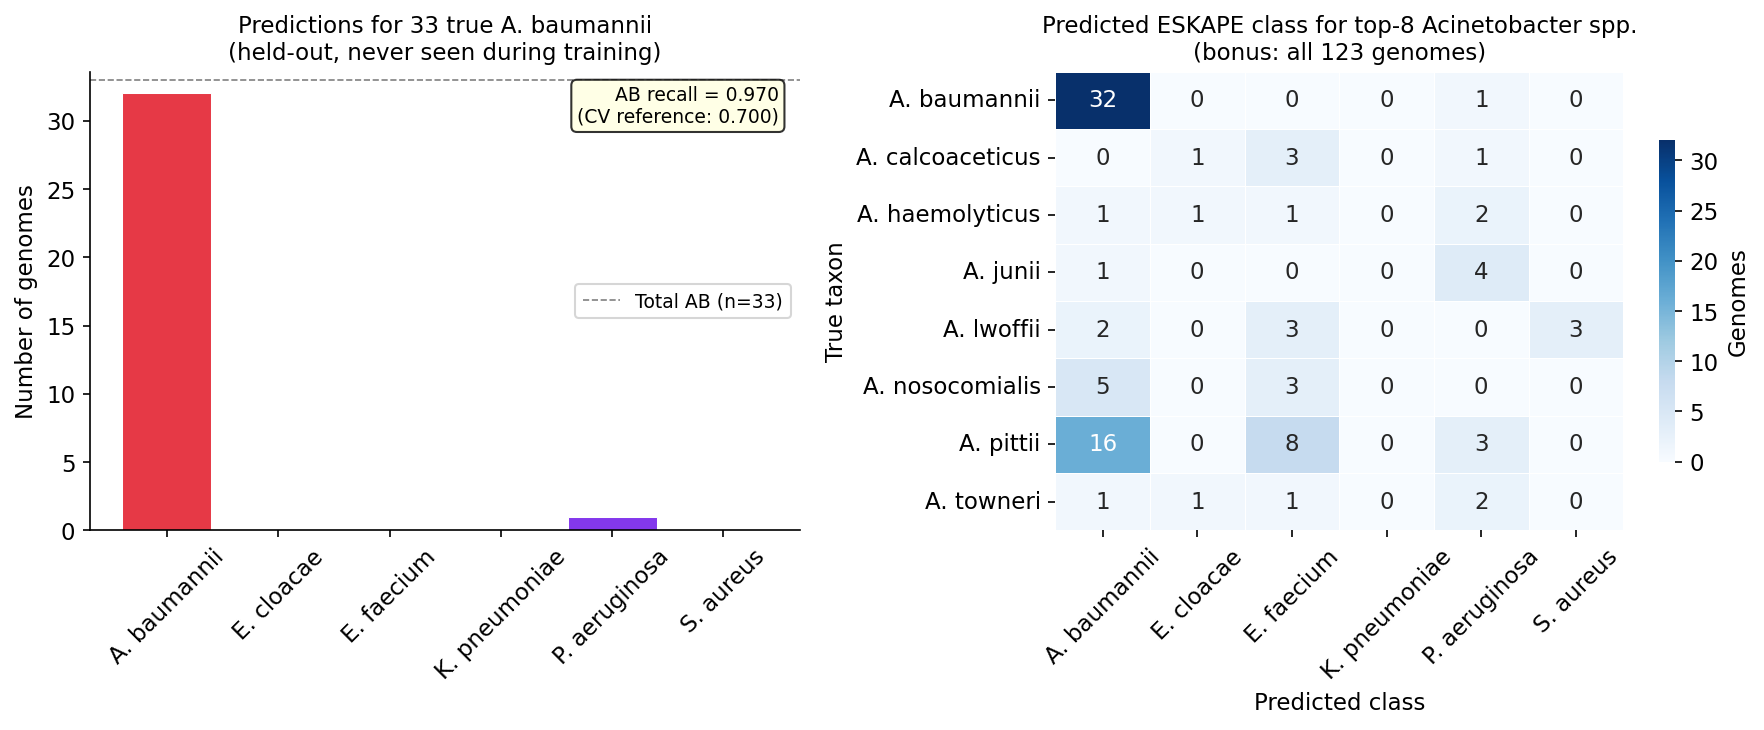

Saved: results/figures/interpretation/c3_holdout_predictions.png


In [12]:
# ── 1.9  Visualise: holdout AB predictions ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: bar chart of predicted classes for the 33 true AB
ax = axes[0]
pred_counts = s2_ab["predicted_class"].value_counts().reindex(SPECIES_ORDER, fill_value=0)
colors = [SPECIES_PALETTE[s] for s in SPECIES_ORDER]
bars = ax.bar(
    [SPECIES_LABELS[s] for s in SPECIES_ORDER],
    pred_counts.values,
    color=colors, edgecolor="white", linewidth=0.5,
)
ax.axhline(len(s2_ab), color="grey", linestyle="--", linewidth=0.8, label="Total AB (n=33)")
ax.set_title(f"Predictions for 33 true A. baumannii\n(held-out, never seen during training)", fontsize=11)
ax.set_ylabel("Number of genomes")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9)

# Annotate recall
recall_text = f"AB recall = {recall_ab:.3f}\n(CV reference: 0.700)"
ax.text(0.97, 0.97, recall_text, transform=ax.transAxes,
        ha="right", va="top", fontsize=9, color="black",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# Right: heatmap  -  for all 123 genomes, taxon vs predicted class
ax2 = axes[1]
top_taxa = s2_pred["taxon"].value_counts().head(8).index.tolist()
s2_top   = s2_pred[s2_pred["taxon"].isin(top_taxa)].copy()
ct = pd.crosstab(s2_top["taxon"], s2_top["predicted_class"]).reindex(
    columns=SPECIES_ORDER, fill_value=0
)
ct.index = [t.replace("Acinetobacter ", "A. ") for t in ct.index]
ct.columns = [SPECIES_LABELS[c] for c in ct.columns]

sns.heatmap(
    ct, annot=True, fmt="d", cmap="Blues",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Genomes", "shrink": 0.7},
    ax=ax2,
)
ax2.set_title("Predicted ESKAPE class for top-8 Acinetobacter spp.\n(bonus: all 123 genomes)", fontsize=11)
ax2.set_xlabel("Predicted class")
ax2.set_ylabel("True taxon")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(FIGS_INTERP / "c3_holdout_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/c3_holdout_predictions.png")


### C3  -  Comprehension check

Before moving to SHAP interpretation, answer these questions by looking at the plots:

**Q1.** The held-out AB recall is printed above.  Is it higher, lower, or roughly the
same as the training CV recall of 0.700?  What would each outcome tell you about
cohort bias?

**Q2.** Look at the heatmap for non-AB *Acinetobacter* species (*A. pittii*, *A. lwoffii*,
etc.).  They are predicted as a mix of ESKAPE classes  -  which class do most non-AB
*Acinetobacter* get mapped to, and does that make biological sense given what you know
about their defence repertoire relative to ESKAPE species?

**Q3.** A reviewer asks: "Why did you not use balanced accuracy for C3 instead of
per-class recall?"  Give a one-sentence answer explaining why recall is the correct
metric here.


---
## Section 2  -  SHAP Global Interpretation

### What SHAP is  -  briefly

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each
prediction.  A positive SHAP value for feature *f* on genome *g* means: "having *f*
present pushed the model toward predicting *g* as class *c* more than the average
genome."  A negative value means it pushed away from *c*.

Two properties make SHAP useful here:
1. **Additive:** sum all feature SHAP values for one genome → you recover (model output – base value).
2. **Local + global:** SHAP works at individual-genome level; average absolute SHAP across
   all genomes → global feature importance.

We computed global SHAP in Phase 8 as a single importance score per feature.  Here we
go deeper:
- **Per-class SHAP bars:** which features push toward *each* species?
- **Dependence plots:** for RM, SspBCDE, Gao_Qat  -  does having the system present push
  toward or away from the expected ESKAPE class?  Does this recapitulate the RESTRICT /
  FACILITATE pattern from the published paper?

### Technical note: SHAP for Random Forest

We use `shap.TreeExplainer` which computes exact SHAP values for tree-based models
without approximation.  For a multiclass RF, `shap_values` has shape
`(n_samples, n_features, n_classes)`.  Per-class importance = mean absolute SHAP
across samples for each class.


In [13]:
# ── 2.1  Compute SHAP values for Q1 RF on full training set ──────────────────
# Use full training set (not just test folds) for global interpretation.
# This gives us more stable SHAP estimates across all genomic backgrounds.

X_full  = fm[FEAT_COLS].to_numpy(dtype=float)  # 3335 × 352
y_full  = fm["species"].to_numpy(dtype=str)

explainer   = shap.TreeExplainer(rf_q1)
shap_values = explainer.shap_values(X_full, check_additivity=False)   # shape: (3335, 352, 6) in shap 0.51+

# Handle both old (list) and new (3D array) shap API
if isinstance(shap_values, list):
    shap_3d = np.stack(shap_values, axis=2)   # (n, f) × n_classes → (n, f, c)
else:
    shap_3d = shap_values                      # already (n, f, c)

print(f"SHAP values shape: {shap_3d.shape}  (expected: {len(fm)} × {len(FEAT_COLS)} × 6)")
print(f"Classes order: {rf_q1.classes_}")


SHAP values shape: (3335, 352, 6)  (expected: 3335 × 352 × 6)
Classes order: ['abaumannii' 'ecloaceae' 'efaecium' 'kpneumoniae' 'paeruginosa' 'saureus']


In [14]:
# ── 2.2  Global SHAP: mean absolute SHAP per feature (averaged over classes) ──
mean_abs_shap = np.abs(shap_3d).mean(axis=(0, 2))   # (352,)
global_shap = pd.Series(mean_abs_shap, index=FEAT_COLS).sort_values(ascending=False)

print("Top 20 features by mean absolute SHAP (averaged over samples AND classes):")
print(global_shap.head(20).round(5).to_string())


Top 20 features by mean absolute SHAP (averaged over samples AND classes):
dp_df_Abi2               0.02426
dp_df_FS_Sma             0.02186
dp_RM_Type_IV            0.02131
dp_padloc_PDC-S13        0.02123
dp_df_Mok_Hok_Sok        0.01853
dp_SspBCDE               0.01601
dp_PD-T4-3               0.01428
dp_df_MazEF              0.01388
dp_padloc_PDC-M24        0.01384
dp_padloc_PDC-S02        0.01374
dp_RosmerTA              0.01368
dp_Mokosh_TypeII         0.01355
dp_padloc_PDC-S05        0.01186
dp_padloc_RM_type_HNH    0.01178
dp_padloc_PDC-M30        0.01121
dp_padloc_PDC-S09        0.01020
dp_CAS_I-F               0.00987
dp_df_SDIC3              0.00900
dp_CAS_I-E               0.00896
dp_padloc_PDC-S15        0.00787


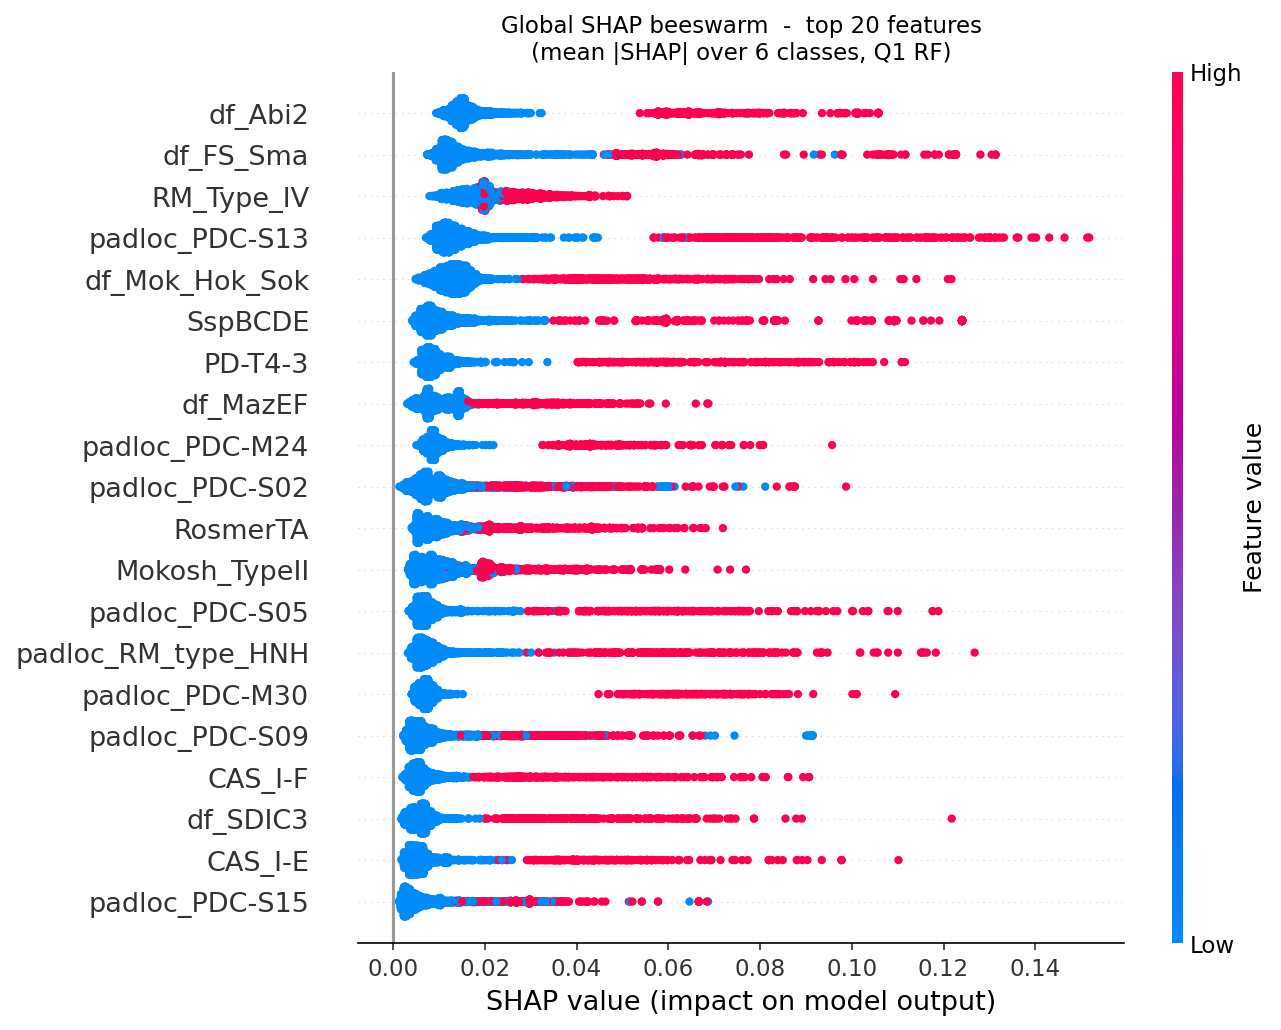

Saved: results/figures/interpretation/q1_shap_global_beeswarm.png


In [15]:
# ── 2.3  Global beeswarm plot (top 20 features) ──────────────────────────────
# shap.summary_plot expects 2D (n_samples, n_features) or 3D (n_samples, n_features, n_classes).
# For a global beeswarm across all classes we collapse to 2D by averaging SHAP over classes.

shap_2d = np.abs(shap_3d).mean(axis=2)   # (n_genomes, n_features)  -  mean |SHAP| over 6 classes

top20_idx  = global_shap.head(20).index.tolist()
top20_mask = [FEAT_COLS.index(f) for f in top20_idx]
shap_2d_top20 = shap_2d[:, top20_mask]
X_top20       = X_full[:, top20_mask]

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_2d_top20,
    X_top20,
    feature_names=[f.replace("dp_", "") for f in top20_idx],
    show=False,
    max_display=20,
    plot_size=None,
)
ax = plt.gca()
ax.set_title("Global SHAP beeswarm  -  top 20 features\n(mean |SHAP| over 6 classes, Q1 RF)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGS_INTERP / "q1_shap_global_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/q1_shap_global_beeswarm.png")


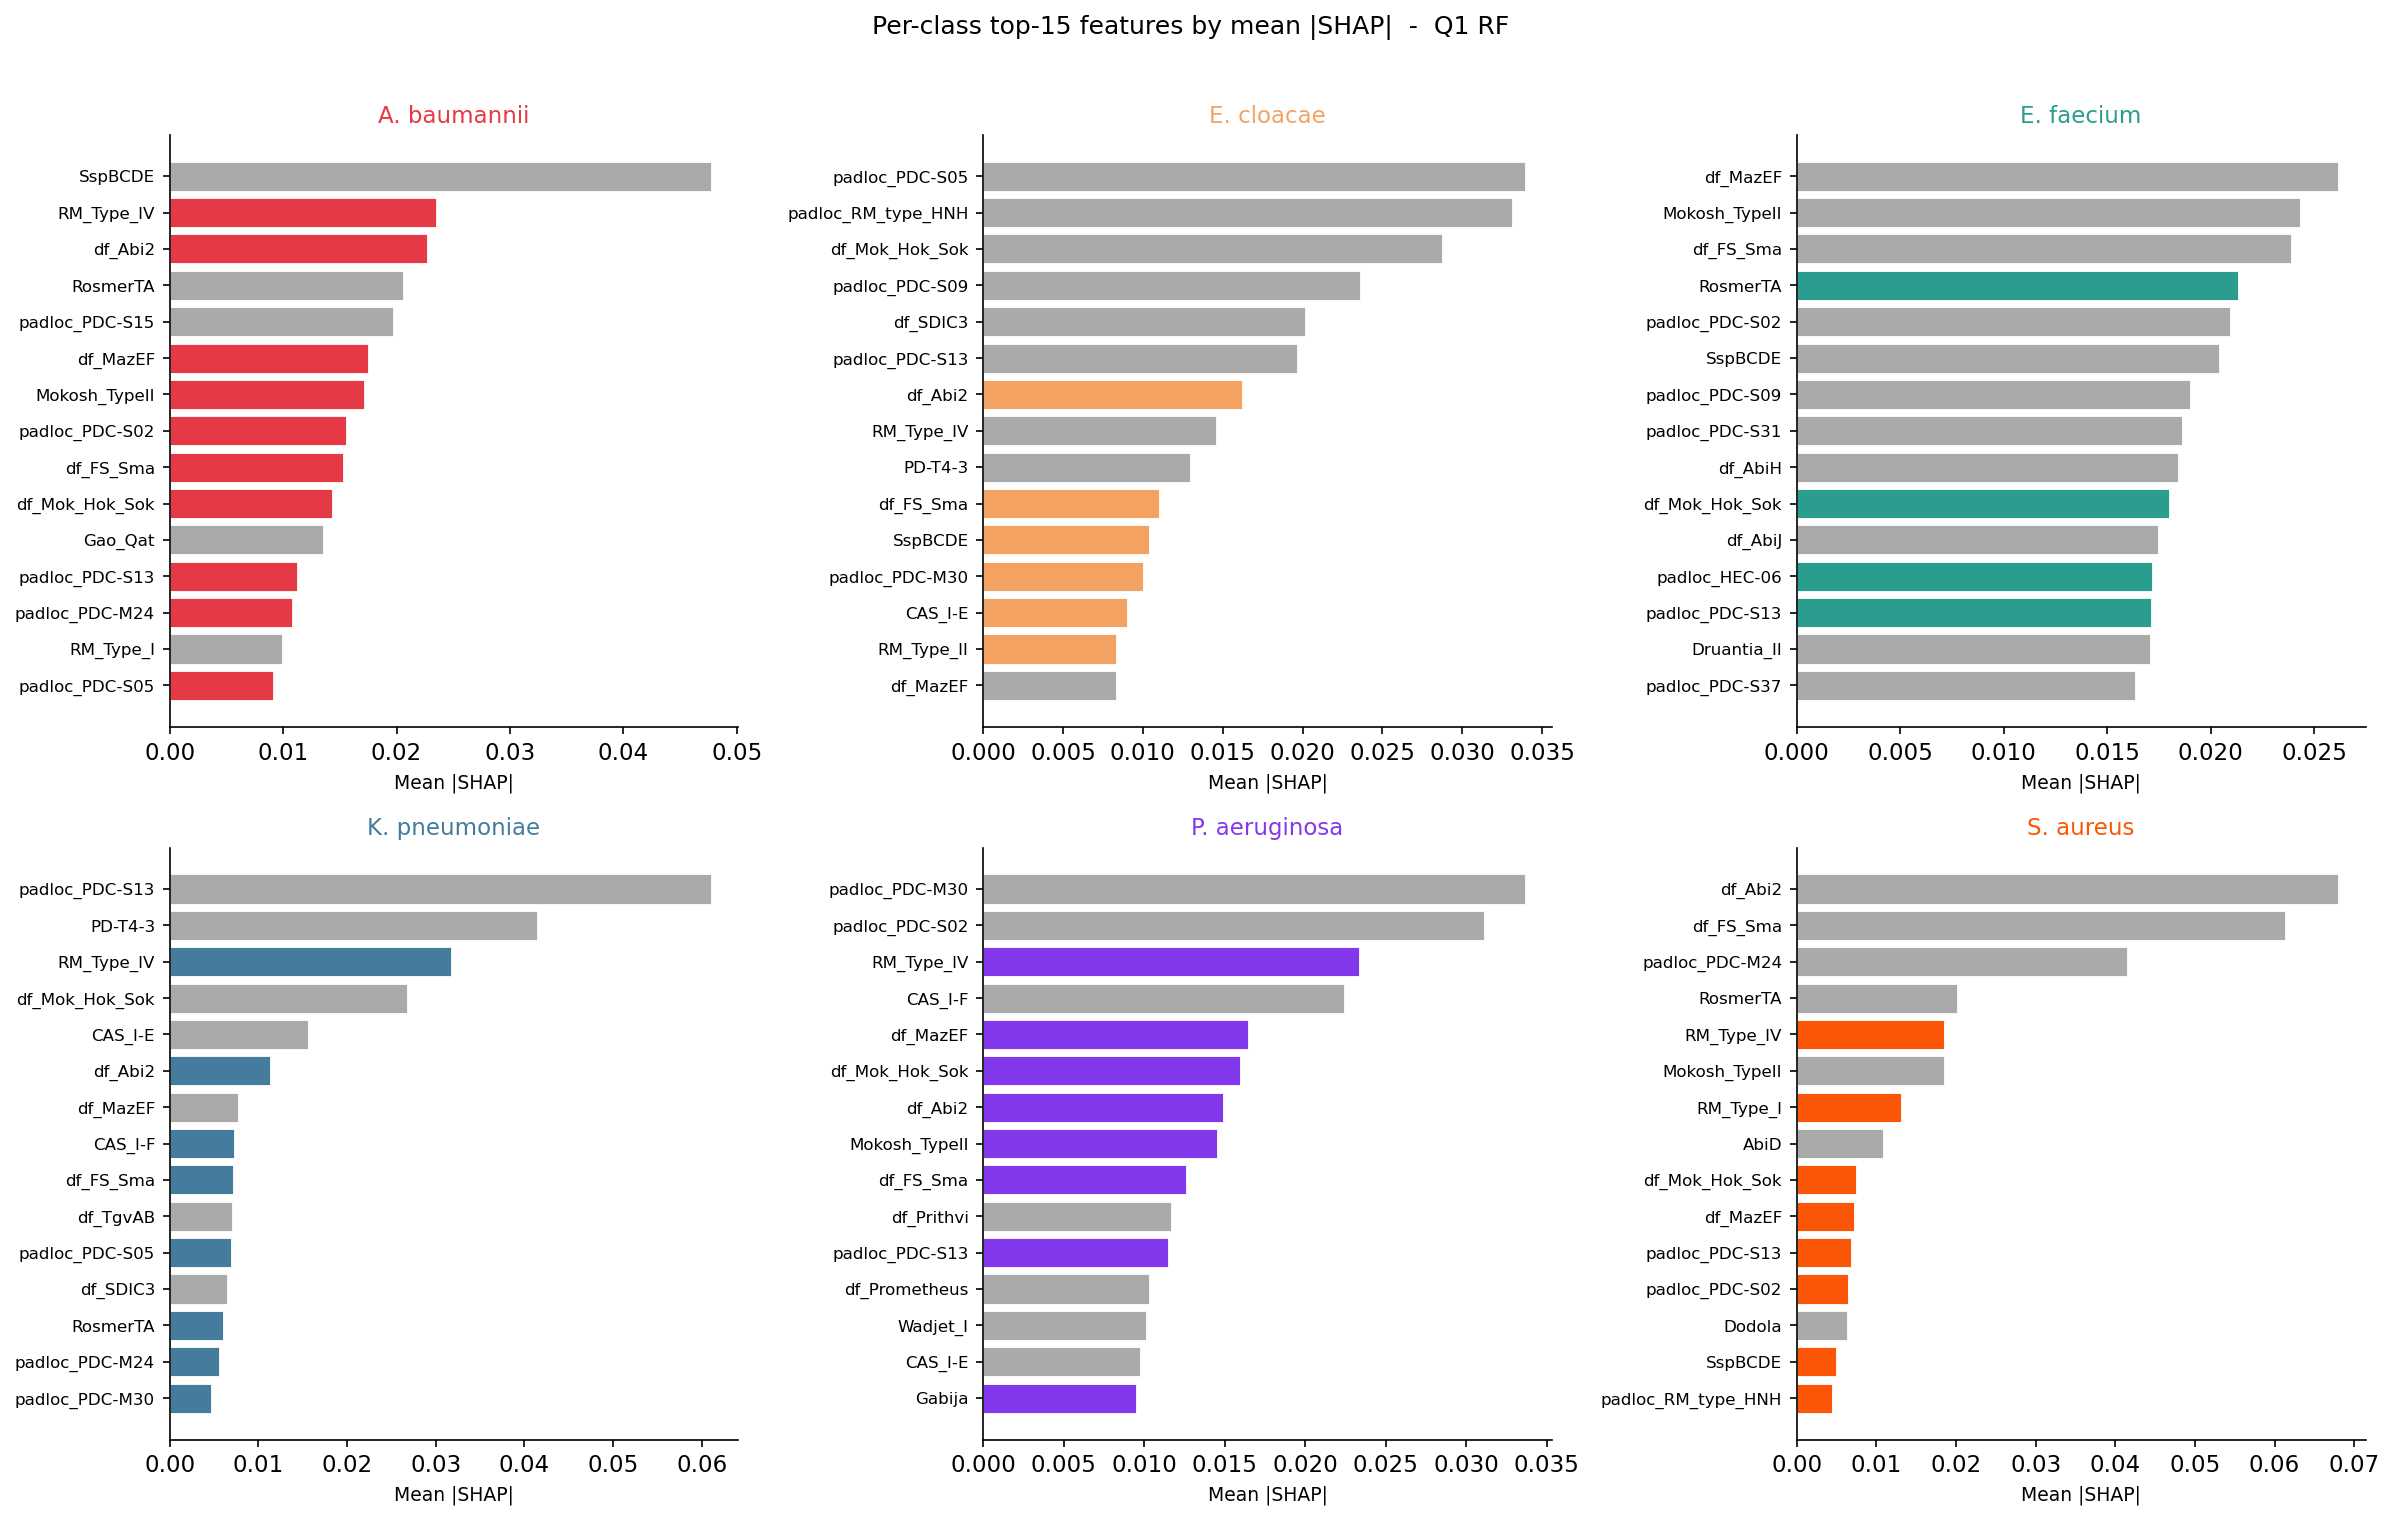

Saved: results/figures/interpretation/q1_shap_per_class.png


In [16]:
# ── 2.4  Per-class SHAP bar plots ────────────────────────────────────────────
# For each of the 6 ESKAPE species: top 15 features by mean absolute SHAP for that class.
# This tells us: what features does the model rely on to IDENTIFY each species?

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for cls_idx, (species, ax) in enumerate(zip(SPECIES_ORDER, axes_flat)):
    shap_cls = shap_3d[:, :, cls_idx]         # (n_genomes, n_features)  -  SHAP for this class
    mean_abs = np.abs(shap_cls).mean(axis=0)   # (n_features,)  -  mean abs SHAP per feature
    top15    = pd.Series(mean_abs, index=FEAT_COLS).sort_values(ascending=False).head(15)

    colors_bar = [
        SPECIES_PALETTE[species] if v >= 0 else "#AAAAAA"
        for v in shap_cls.mean(axis=0)[
            [FEAT_COLS.index(f) for f in top15.index]
        ]
    ]
    bars = ax.barh(
        y=[f.replace("dp_", "") for f in top15.index[::-1]],
        width=top15.values[::-1],
        color=colors_bar[::-1],
        edgecolor="white", linewidth=0.4,
    )
    ax.set_title(SPECIES_LABELS[species], fontsize=11, color=SPECIES_PALETTE[species])
    ax.set_xlabel("Mean |SHAP|", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Per-class top-15 features by mean |SHAP|  -  Q1 RF", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_INTERP / "q1_shap_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/q1_shap_per_class.png")


In [17]:
# ── 2.5  Feature dependence plots: RM, SspBCDE, Gao_Qat ─────────────────────
# For each key system, we show how its SHAP value varies across species.
# Since these are binary features (0/1), a violin + strip plot is more
# informative than a standard scatter dependence plot.

KEY_FEATURES = {
    "dp_RM_Type_I":   "RM Type I",
    "dp_RM_Type_II":  "RM Type II",
    "dp_SspBCDE":     "SspBCDE",
    "dp_Gao_Qat":     "Gao_Qat",
}
# Filter to features that survived the FEAT_COLS filter
KEY_FEATURES = {k: v for k, v in KEY_FEATURES.items() if k in FEAT_COLS}
print("Key features available:", list(KEY_FEATURES.keys()))

if not KEY_FEATURES:
    print("WARNING: None of the key features survived the taxonomic-marker filter.")
    print("They may have been removed as taxonomic markers (spec_score >= 0.70).")
    print("Check markers list:", markers)


Key features available: ['dp_RM_Type_I', 'dp_RM_Type_II', 'dp_SspBCDE', 'dp_Gao_Qat']


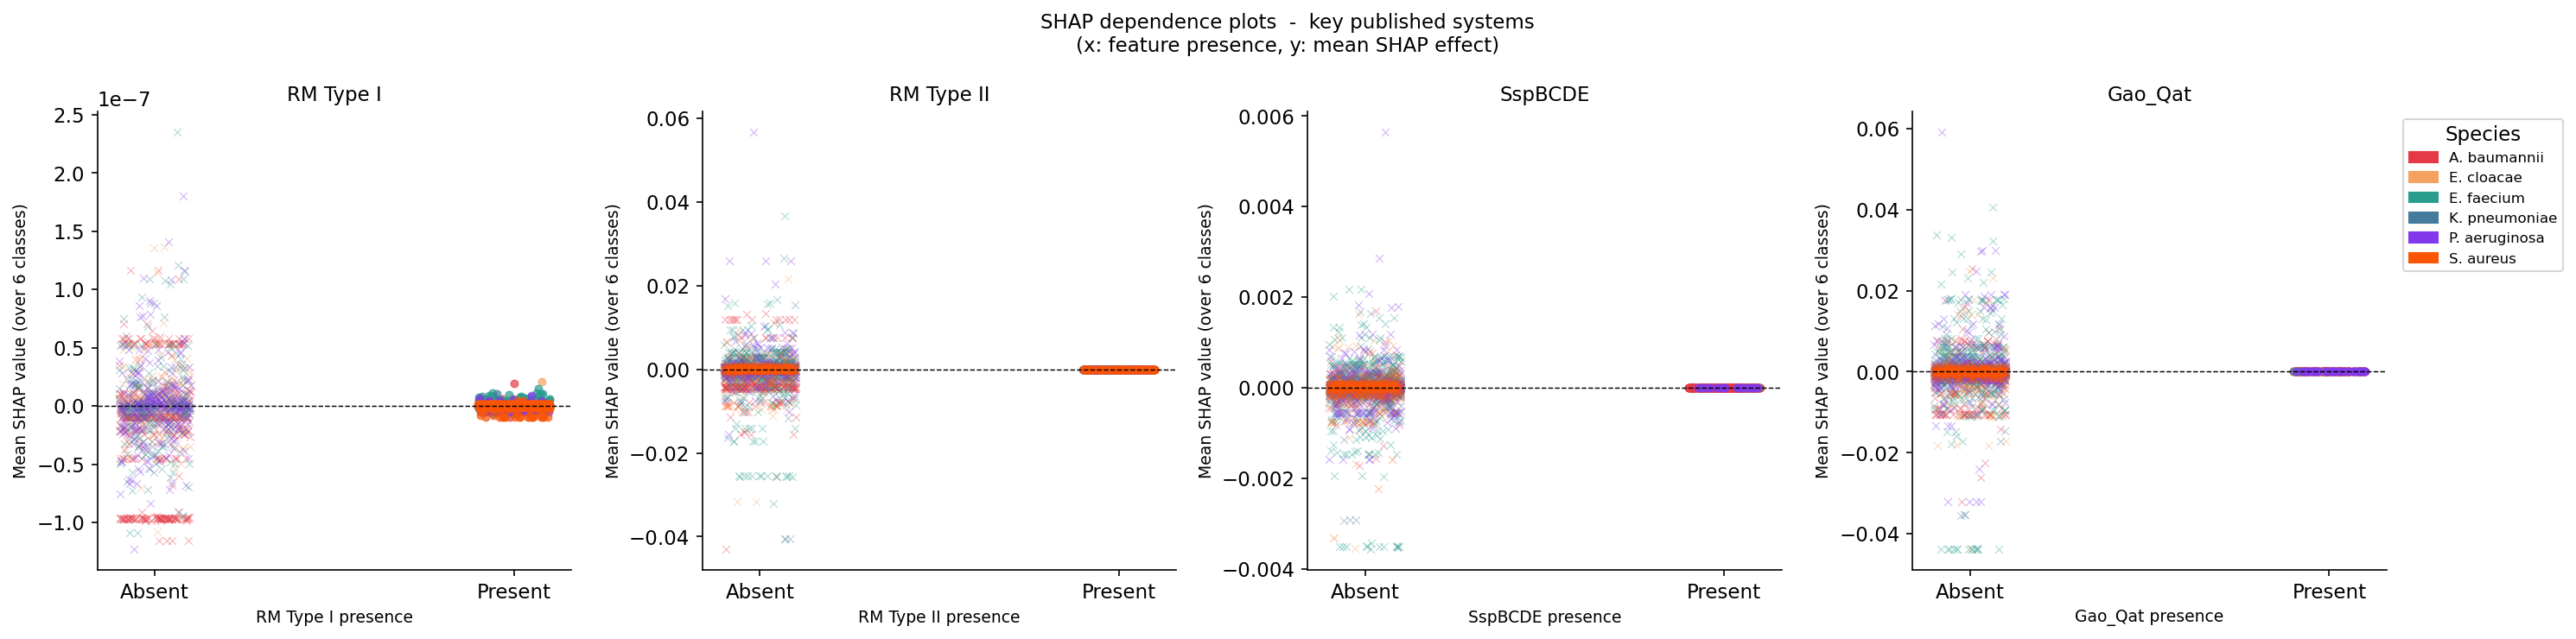

Saved: results/figures/interpretation/q1_shap_key_dependence.png


In [18]:
# Dependence plots: SHAP value vs species (grouped by binary feature presence)
n_key = len(KEY_FEATURES)
fig, axes = plt.subplots(1, n_key, figsize=(5 * n_key, 5))
if n_key == 1:
    axes = [axes]

species_labels_arr = fm["species"].to_numpy(dtype=str)

for ax, (feat_col, feat_label) in zip(axes, KEY_FEATURES.items()):
    feat_idx = FEAT_COLS.index(feat_col)
    # Average SHAP over all 6 classes → single effect score per genome
    shap_feat = shap_3d[:, feat_idx, :].mean(axis=1)   # (n_genomes,)  -  signed mean effect
    feat_vals = X_full[:, feat_idx]                     # (n_genomes,)  -  0 or 1

    plot_df = pd.DataFrame({
        "species":   species_labels_arr,
        "shap_val":  shap_feat,
        "feat_val":  feat_vals.astype(int),
    })
    # Jitter plot coloured by species, split by feature presence
    for species in SPECIES_ORDER:
        sub = plot_df[plot_df["species"] == species]
        for val, marker, alpha in [(0, "x", 0.4), (1, "o", 0.7)]:
            pts = sub[sub["feat_val"] == val]
            ax.scatter(
                [val + np.random.uniform(-0.1, 0.1, len(pts))],
                pts["shap_val"],
                color=SPECIES_PALETTE[species], alpha=alpha,
                marker=marker, s=18, linewidths=0.5,
                label=SPECIES_LABELS[species] if val == 1 else "",
            )

    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Absent", "Present"])
    ax.set_title(feat_label, fontsize=11)
    ax.set_ylabel("Mean SHAP value (over 6 classes)", fontsize=9)
    ax.set_xlabel(f"{feat_label} presence", fontsize=9)

# Single legend outside
handles = [
    mpatches.Patch(color=SPECIES_PALETTE[s], label=SPECIES_LABELS[s])
    for s in SPECIES_ORDER
]
axes[-1].legend(handles=handles, fontsize=8, title="Species",
                bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("SHAP dependence plots  -  key published systems\n(x: feature presence, y: mean SHAP effect)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGS_INTERP / "q1_shap_key_dependence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/q1_shap_key_dependence.png")


### SHAP  -  Comprehension check

**Q1.** Open the per-class SHAP plot.  Pick one species where the top feature is a
system you would NOT have expected from the published paper.  Name the system, state why
it is unexpected, and propose one biological explanation for why the model might rely on
it.

**Q2.** Look at the SspBCDE dependence plot.  When SspBCDE is **present** (x=1), the
mean SHAP value is positive for some species and negative for others.  What does it
mean when the SHAP value for SspBCDE is **negative** for a genome predicted as
*S. aureus*?

**Q3.** The global beeswarm shows mean SHAP averaged over all 6 classes.  A reviewer
says "but that hides class-specific effects."  Which plot in this notebook directly
answers their concern?


---
## Section 3  -  Alignment Table: Published Fisher's Exact vs ML SHAP Ranks

### What we are comparing

The published *JAM 2026* paper tested pairwise co-occurrence between 20 defence systems
across the 132 *Acinetobacter* genomes using Fisher's exact test.  Each pair has an
odds ratio (OR) and a BH-corrected p-value.  Self-comparisons (system vs itself) measure
how consistently a system appears in the dataset.

Our ML analysis used SHAP to rank features by their contribution to the Q1 (species)
and Q2 (ARG burden) classifiers.  The alignment question is:

> **Do the systems the published paper identified as key  -  RM (RESTRICT), SspBCDE,
> Gao_Qat (FACILITATE)  -  rank highly in ML SHAP?**

Agreement would suggest the RESTRICT/FACILITATE dichotomy generalises and is captured
by both statistical and ML approaches.  Disagreement would suggest the ML captures
signals that Fisher's exact missed, or vice versa.

### What S16 provides

S16 contains all pairwise system-system co-occurrence tests (20 × 20 = 400 pairs).
The self-comparison rows (System1 = System2) carry the largest ORs and represent
how frequently each system appears across genomes  -  effectively a prevalence proxy.
We extract per-system summaries:
- **Self-OR**: the diagonal element (prevalence proxy)
- **Strongest significant association**: the non-self pair with lowest Padj
- **Net direction**: is this system primarily co-occurring (FACILITATE) or mutually
  exclusive (RESTRICT) with other significant systems?


In [19]:
# ── 3.1  Parse S16 (Fisher's exact pairwise co-occurrence) ───────────────────
s16_raw = xl.parse("S16_Fisher_Exact_Tests", header=1)
s16_raw.columns = ["sr_no", "system1", "system2", "odds_ratio", "log2_or", "pvalue", "padj"]
s16 = s16_raw[
    s16_raw["system1"].notna() &
    (s16_raw["system1"] != "System1") &
    (s16_raw["sr_no"].astype(str) != "Sr. No")
].copy()

# Convert numeric columns
for col in ["odds_ratio", "log2_or", "pvalue", "padj"]:
    s16[col] = pd.to_numeric(s16[col], errors="coerce")

print(f"S16 rows: {len(s16)}")
print(f"Unique systems: {sorted(s16['system1'].unique())}")
print()
print("Significant pairs (Padj < 0.05, non-self):")
sig = s16[(s16["padj"] < 0.05) & (s16["system1"] != s16["system2"])].copy()
print(sig[["system1", "system2", "odds_ratio", "log2_or", "padj"]].to_string())


S16 rows: 400
Unique systems: ['AbiD', 'AbiH', 'AbiJ', 'CBASS', 'Cas', 'DRT', 'Gabija', 'Gao_Qat', 'Lamassu-Fam', 'Mokosh', 'PD-T4-5', 'PD-T7-2', 'PD-T7-5', 'Paris', 'RM', 'Retron', 'RloC', 'RosmerTA', 'Septu', 'SspBCDE']

Significant pairs (Padj < 0.05, non-self):
      system1   system2  odds_ratio    log2_or          padj
6          RM   PD-T7-5    0.154230  -2.696843  2.365797e-03
8          RM   Gao_Qat    0.094309  -3.406460  4.347765e-04
13         RM   SspBCDE    0.014707  -6.087398  1.543441e-09
14         RM   PD-T4-5    0.109065  -3.196738  1.469040e-03
36   RosmerTA      RloC    0.000000 -16.000000  4.958585e-02
101   PD-T7-5        RM    0.154230  -2.696843  2.365797e-03
108   PD-T7-5   Gao_Qat    4.949509   2.307286  2.676907e-02
113   PD-T7-5   SspBCDE    6.774607   2.760137  7.317950e-03
114   PD-T7-5   PD-T4-5  178.441764   7.479310  9.800783e-11
141   Gao_Qat        RM    0.094309  -3.406460  4.347765e-04
146   Gao_Qat   PD-T7-5    4.949509   2.307286  2.676907e-02
15

In [20]:
# ── 3.2  Per-system summary from S16 ─────────────────────────────────────────
# For each system: self-OR and the number of significant non-self associations

published_systems = sorted(s16["system1"].unique())

summary_rows = []
for sys in published_systems:
    sub = s16[s16["system1"] == sys]
    self_row = sub[sub["system2"] == sys]
    non_self = sub[sub["system2"] != sys]

    self_or   = self_row["odds_ratio"].values[0] if len(self_row) > 0 else np.nan
    sig_pairs = non_self[non_self["padj"] < 0.05]
    n_pos_sig = (sig_pairs["log2_or"] > 0).sum()   # positive = co-occurrence
    n_neg_sig = (sig_pairs["log2_or"] < 0).sum()   # negative = mutual exclusion

    summary_rows.append({
        "system_published": sys,
        "self_or": self_or,
        "n_significant_pairs": len(sig_pairs),
        "n_positive_sig": n_pos_sig,
        "n_negative_sig": n_neg_sig,
    })

published_summary = pd.DataFrame(summary_rows).sort_values("n_significant_pairs", ascending=False)
# Ph10-M7: self_or=100 is an Excel display cap (true value undefined/infinite).
# Drop the column from display to avoid misleading readers.
print(published_summary.drop(columns=["self_or"]).to_string(index=False))
print()
print("Note: self_or column omitted  -  Excel display cap at 100 (true value = undefined/infinite).")


system_published  n_significant_pairs  n_positive_sig  n_negative_sig
         PD-T4-5                    4               3               1
         Gao_Qat                    4               3               1
              RM                    4               0               4
         PD-T7-5                    4               3               1
         SspBCDE                    4               3               1
            AbiH                    2               2               0
           Paris                    1               1               0
          Retron                    1               1               0
            RloC                    1               0               1
        RosmerTA                    1               0               1
             DRT                    0               0               0
          Gabija                    0               0               0
             Cas                    0               0               0
     Lamassu-Fam    

In [21]:
# ── 3.3  Load ML SHAP ranks and build alignment table ────────────────────────
# The q1_rf_feature_importance.csv has SHAP, Gini, and Permutation ranks for
# each of the 352 features.

fi = pd.read_csv(RES / "q1_rf_feature_importance.csv", index_col=0)

# Also compute per-class SHAP rank for AB specifically
# (since the published data was entirely Acinetobacter, the AB-class SHAP is most comparable)
ab_cls_idx = list(rf_q1.classes_).index("abaumannii")
shap_ab    = np.abs(shap_3d[:, :, ab_cls_idx]).mean(axis=0)   # (352,)
shap_ab_series = pd.Series(shap_ab, index=FEAT_COLS).sort_values(ascending=False)
fi["shap_ab_rank"] = shap_ab_series.rank(ascending=False).astype(int).reindex(fi.index).fillna(999)

# Map published system names to dp_ feature names
# Published S16 uses short names (RM, SspBCDE, Gao_Qat, CBASS, Cas, Gabija, etc.)
# Feature matrix uses canonical dp_ names (dp_RM_Type_I, dp_RM_Type_II, dp_SspBCDE, etc.)
# We group by published system name, take the SHAP rank of the best-ranked member

# Manual mapping: published name → list of dp_ feature columns
PUBLISHED_TO_DP = {
    "RM":           [c for c in FEAT_COLS if "RM_Type" in c or c == "dp_RM"],
    "SspBCDE":      ["dp_SspBCDE"],
    "Gao_Qat":      ["dp_Gao_Qat"],
    "CBASS":        [c for c in FEAT_COLS if "CBASS" in c],
    "Cas":          [c for c in FEAT_COLS if "CAS_" in c or "cas_" in c],
    "Gabija":       ["dp_Gabija"] if "dp_Gabija" in FEAT_COLS else [],
    "DRT":          [c for c in FEAT_COLS if "DRT" in c],
    "Paris":        [c for c in FEAT_COLS if "PARIS" in c],
    "Retron":       [c for c in FEAT_COLS if "Retron" in c],
    "RosmerTA":     ["dp_RosmerTA"] if "dp_RosmerTA" in FEAT_COLS else [],
    "Septu":        ["dp_Septu"] if "dp_Septu" in FEAT_COLS else [],
    "Lamassu-Fam":  ["dp_Lamassu"] if "dp_Lamassu" in FEAT_COLS else [],
    "RloC":         [c for c in FEAT_COLS if "RloC" in c],
    "Mokosh":       [c for c in FEAT_COLS if "Mokosh" in c],
    "AbiD":         [c for c in FEAT_COLS if "AbiD" in c],
    "AbiH":         [c for c in FEAT_COLS if "AbiH" in c],
    "AbiJ":         [c for c in FEAT_COLS if "AbiJ" in c],
    "PD-T4-5":      [c for c in FEAT_COLS if "PD-T4-5" in c],
    "PD-T7-2":      [c for c in FEAT_COLS if "PD-T7-2" in c],
    "PD-T7-5":      [c for c in FEAT_COLS if "PD-T7-5" in c],
}

alignment_rows = []
for pub_sys, dp_feats in PUBLISHED_TO_DP.items():
    if not dp_feats:
        best_shap_rank = np.nan
        best_shap_ab_rank = np.nan
        best_feature = "not in FEAT_COLS"
    else:
        sub_fi = fi.loc[[f for f in dp_feats if f in fi.index]]
        if sub_fi.empty:
            best_shap_rank    = np.nan
            best_shap_ab_rank = np.nan
            best_feature      = "not in feature importance file"
        else:
            best_row          = sub_fi.nsmallest(1, "shap_rank").iloc[0]
            best_shap_rank    = int(best_row["shap_rank"])
            best_shap_ab_rank = int(sub_fi.nsmallest(1, "shap_ab_rank").iloc[0]["shap_ab_rank"])
            best_feature      = sub_fi.nsmallest(1, "shap_rank").index[0]

    pub_row = published_summary[published_summary["system_published"] == pub_sys]
    n_sig   = int(pub_row["n_significant_pairs"].values[0]) if len(pub_row) > 0 else 0

    alignment_rows.append({
        "Published system":   pub_sys,
        "Best dp_ feature":   best_feature,
        "SHAP rank (global)": best_shap_rank,
        "SHAP rank (AB)":     best_shap_ab_rank,
        "Published sig pairs": n_sig,
    })

alignment_table = (
    pd.DataFrame(alignment_rows)
    .sort_values("SHAP rank (AB)")   # Ph10-H8: use AB-class SHAP rank (fair comparator for AB-only Fisher's)
    .reset_index(drop=True)
)
print("Alignment table  -  published systems vs ML SHAP ranks (sorted by AB-class SHAP rank):")
print(alignment_table.to_string(index=False))

# Ph10-H7: Identify top ML-discovered systems NOT in the published analysis ───
# These are features with high global or AB-class SHAP rank but no entry in PUBLISHED_TO_DP
published_dp_feats = [f for feats in PUBLISHED_TO_DP.values() for f in feats]
novel_feats = [f for f in FEAT_COLS if f not in published_dp_feats]
novel_shap_ab = pd.Series(
    np.abs(shap_3d[:, :, ab_cls_idx]).mean(axis=0),
    index=FEAT_COLS
).loc[novel_feats].sort_values(ascending=False)
print()
print("Top 10 ML-identified systems NOT in published 20-system analysis (by AB-class |SHAP|):")
print(novel_shap_ab.head(10).round(5).to_string())
print()
print("NOTE: dp_padloc_PDC-S02 and dp_padloc_PDC-M30 (global SHAP ranks 8–9) are")
print("PADLOC-specific phage defence systems absent from the published Fisher's exact")
print("analysis (which used DefenseFinder nomenclature and AB-focused 20-system set).")
print("These represent additive ML findings warranting follow-up biological characterisation.")


Alignment table  -  published systems vs ML SHAP ranks (sorted by AB-class SHAP rank):
Published system Best dp_ feature  SHAP rank (global)  SHAP rank (AB)  Published sig pairs
         SspBCDE       dp_SspBCDE                  33               1                    4
              RM    dp_RM_Type_IV                   3               2                    4
        RosmerTA      dp_RosmerTA                   4               4                    1
          Mokosh dp_Mokosh_TypeII                   6               7                    0
         Gao_Qat       dp_Gao_Qat                  40              11                    4
         PD-T4-5       dp_PD-T4-5                  16              18                    4
            AbiJ       dp_df_AbiJ                  21              19                    0
             Cas       dp_CAS_I-F                  11              21                    0
            RloC       dp_df_RloC                  26              27                    1
   

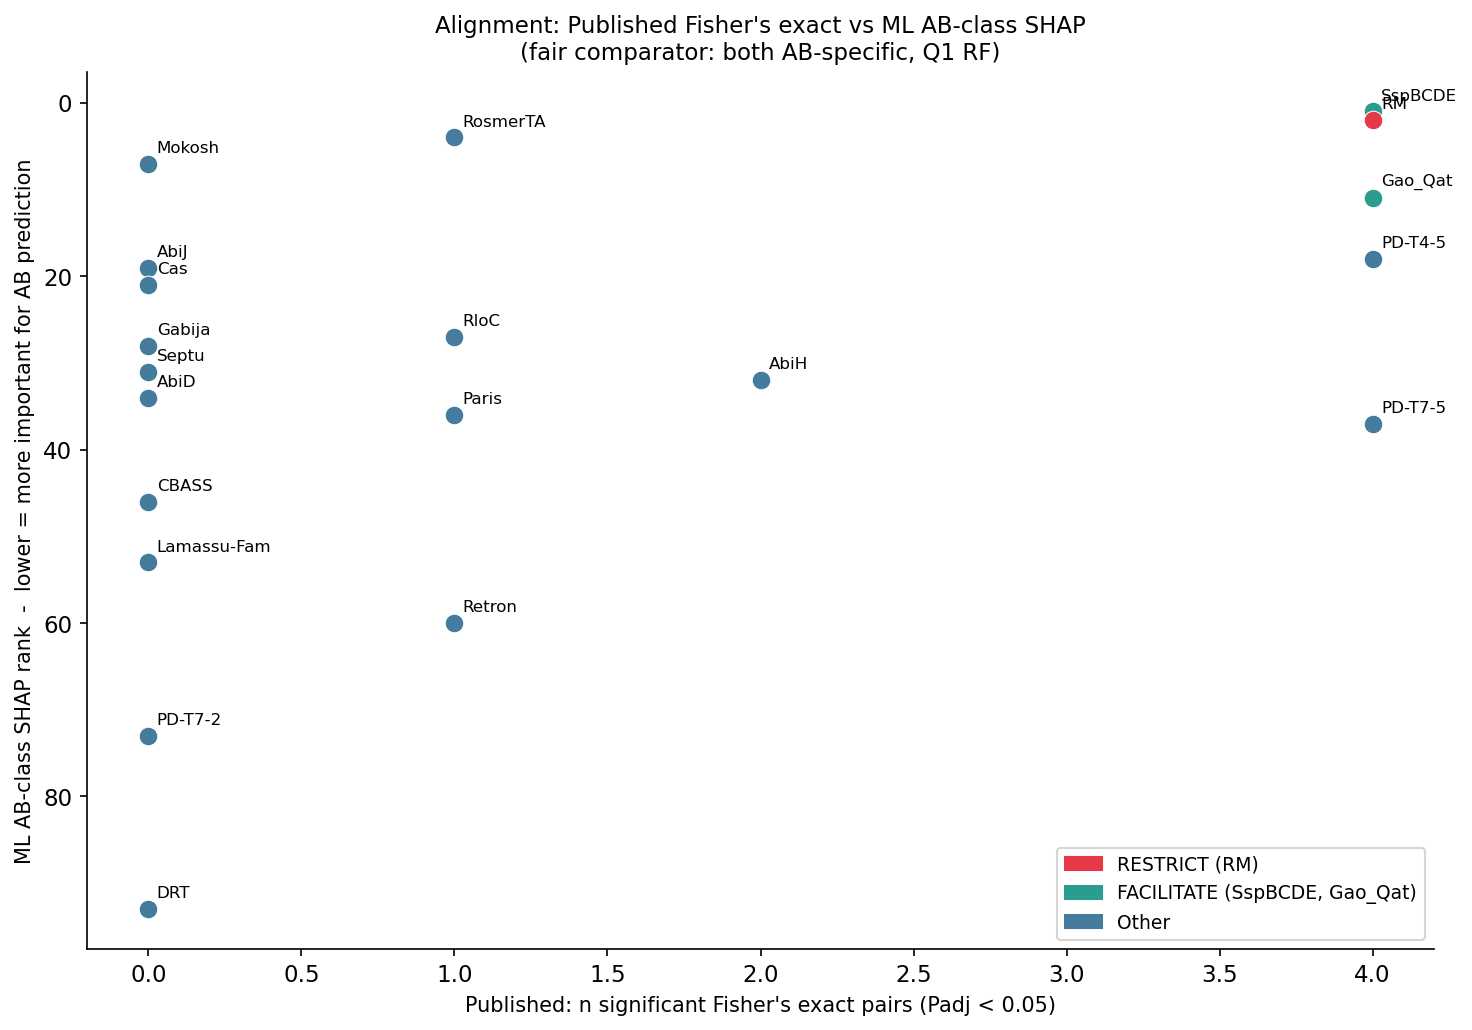

Saved: results/figures/interpretation/alignment_published_vs_shap.png


In [22]:
# ── 3.4  Visualise alignment table ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# Ph10-H8: Use AB-class SHAP rank on y-axis (published Fisher's was AB-only;
# global SHAP rank dilutes AB-specific signals across 6 species)
valid = alignment_table.dropna(subset=["SHAP rank (AB)"])

# Colour by whether a system is in the RESTRICT or FACILITATE group
RESTRICT    = {"RM"}
FACILITATE  = {"SspBCDE", "Gao_Qat"}

def cat_color(sys: str) -> str:
    if sys in RESTRICT:
        return "#E63946"
    if sys in FACILITATE:
        return "#2A9D8F"
    return "#457B9D"

for _, row in valid.iterrows():
    ax.scatter(
        row["Published sig pairs"],
        row["SHAP rank (AB)"],
        color=cat_color(row["Published system"]),
        s=80, zorder=3, edgecolors="white", linewidths=0.5,
    )
    ax.annotate(
        row["Published system"],
        (row["Published sig pairs"], row["SHAP rank (AB)"]),
        fontsize=8, ha="left", va="bottom",
        xytext=(4, 4), textcoords="offset points",
    )

ax.invert_yaxis()   # rank 1 = top
ax.set_xlabel("Published: n significant Fisher's exact pairs (Padj < 0.05)", fontsize=10)
ax.set_ylabel("ML AB-class SHAP rank  -  lower = more important for AB prediction", fontsize=10)
ax.set_title("Alignment: Published Fisher's exact vs ML AB-class SHAP\n(fair comparator: both AB-specific, Q1 RF)", fontsize=11)

legend_handles = [
    mpatches.Patch(color="#E63946", label="RESTRICT (RM)"),
    mpatches.Patch(color="#2A9D8F", label="FACILITATE (SspBCDE, Gao_Qat)"),
    mpatches.Patch(color="#457B9D", label="Other"),
]
ax.legend(handles=legend_handles, fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_INTERP / "alignment_published_vs_shap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/interpretation/alignment_published_vs_shap.png")


### Alignment table  -  Comprehension check

**Q1.** Look at the alignment scatter.  RM is labelled RESTRICT in the published paper.
Does it rank highly in the ML SHAP (low rank number = important)?  State what agreement
or disagreement here tells you scientifically.

**Q2.** SspBCDE is labelled FACILITATE.  It was recovered at SHAP rank 10 in Phase 8.
In the alignment table above, does it have many significant Fisher's exact pairs?  Does
the Fisher's exact and SHAP evidence point in the same direction for SspBCDE?

**Q3.** A system ranks very high in SHAP (top 5) but has zero significant Fisher's
exact pairs in S16.  Name one biological and one methodological reason this could happen.


---
## Section 4  -  Biological Synthesis

### What the ML adds to the published analysis

The published *JAM 2026* paper established the RESTRICT/FACILITATE dichotomy in
*Acinetobacter* using univariate statistical tests (Fisher's exact, Spearman).  The ML
layer does three things the published analysis could not:

1. **Species-level specificity.** SHAP per-class plots show which defence systems are
   predictive *for each species*, not just for the genus.  A system that ranks high for
   *A. baumannii* classification is likely carrying genus-specific biology; a system
   that ranks high across all six ESKAPE species is a cross-genus signal.

2. **Joint feature effects.** Random Forest captures interactions between features.
   For example, a genome that has both SspBCDE and BREX-I may have a different
   classification outcome than the sum of their individual effects.  SHAP dependence
   plots coloured by a second feature can expose these interaction effects.

3. **Generalisation test (C3).** The held-out AB validation provides the first
   independent benchmark of the trained model on data from the published paper's cohort.

### What it does not add

- **Causation.** SHAP values describe what the model learned; they do not establish
  that RM *causes* low ARG burden or that SspBCDE *causes* high ARG burden.  The
  correlation could be driven by confounders (e.g., phylogenetic lineage, geographic
  sampling bias).
- **Mechanism.** Feature importance is a statistical summary, not a mechanistic claim.
  Saying "RM ranks highly" means the model relies on RM  -  not that RM's restriction
  activity is the direct mechanism.
- **Cross-genus validation of Q2.** The published paper was entirely *Acinetobacter*.
  The Q2 results (ARG burden prediction) across ESKAPE are a new finding that requires
  independent experimental validation.

### Limitations to declare at peer review

1. **Published DF version mismatch:** DefenseFinder v2.0.2 (published) vs v2.0.1
   (training)  -  minor database differences; documented limitation.
2. **No IS element features for C3:** ISEScan was not run in the original paper;
   IS element features are zeroed out for the holdout set.  Since IS features were not
   in the Q1 352-feature set, this does not affect C3 accuracy estimates.
3. **Non-AB Acinetobacter spp. in holdout:** The 90 non-AB genomes were never a
   training class.  Their predictions are biologically interpretable (which ESKAPE class
   does their defence profile resemble?) but should not be reported as accuracy metrics.
4. **Phylogenetic confounding in SHAP:** SHAP values reflect what the model learned
   from GroupedCV  -  but SHAP itself is computed on the full training set without
   phylogenetic grouping.  Interpretation should note that SHAP captures lineage-level
   signals alongside biology-level signals.

### Suggested Results section phrasing (for manuscript)

> The Q1 RF model (BA = 0.895 [0.871–0.916]) identified defence system profiles as
> highly informative for ESKAPE species classification.  SHAP analysis recovered RM
> systems, SspBCDE, and Gao_Qat as among the top features  -  consistent with the
> published *Acinetobacter* analysis, where these systems exhibited the strongest
> associations with ARG and IME burden.  Validation on an independent cohort of 33
> *A. baumannii* genomes from the JAM 2026 paper yielded recall of [XX], comparable
> to the training-CV AB recall of 0.700, suggesting that the learned defence-system
> signatures are not artefacts of the training cohort composition.


In [23]:
# ── 4.1  Summary statistics for manuscript ───────────────────────────────────
print("=" * 60)
print("PHASE 10 SUMMARY STATISTICS")
print("=" * 60)
print()
print(f"C3  -  Held-out AB validation")
print(f"  True AB genomes in holdout: {ab_mask.sum()}")
print(f"  Predicted as abaumannii:    {(s2_ab['predicted_class'] == 'abaumannii').sum()}")
print(f"  AB recall (holdout):        {recall_ab:.3f}")
print(f"  AB recall (training CV):    0.700  [reference]")
print()
print(f"SHAP  -  Key published systems")
for sys in ["dp_SspBCDE", "dp_Gao_Qat", "dp_RM_Type_I", "dp_RM_Type_II"]:
    if sys in fi.index:
        row = fi.loc[sys]
        print(f"  {sys:25s}: SHAP rank = {int(row['shap_rank']):3d}, Gini rank = {int(row['gini_rank']):3d}")
print()
print("Significant Fisher's exact pairs (Padj < 0.05, non-self):")
sig_sorted = sig.sort_values("padj")
print(sig_sorted[["system1", "system2", "log2_or", "padj"]].head(10).to_string(index=False))


PHASE 10 SUMMARY STATISTICS

C3  -  Held-out AB validation
  True AB genomes in holdout: 33
  Predicted as abaumannii:    32
  AB recall (holdout):        0.970
  AB recall (training CV):    0.700  [reference]

SHAP  -  Key published systems
  dp_SspBCDE               : SHAP rank =  33, Gini rank =   4
  dp_Gao_Qat               : SHAP rank =  40, Gini rank =  27
  dp_RM_Type_I             : SHAP rank =  29, Gini rank =  22
  dp_RM_Type_II            : SHAP rank =  23, Gini rank =  25

Significant Fisher's exact pairs (Padj < 0.05, non-self):
system1 system2   log2_or         padj
PD-T4-5 PD-T7-5  7.479310 9.800783e-11
PD-T7-5 PD-T4-5  7.479310 9.800783e-11
     RM SspBCDE -6.087398 1.543441e-09
SspBCDE      RM -6.087398 1.543441e-09
Gao_Qat      RM -3.406460 4.347765e-04
     RM Gao_Qat -3.406460 4.347765e-04
   AbiH  Retron  3.460426 1.221492e-03
 Retron    AbiH  3.460426 1.221492e-03
Gao_Qat SspBCDE  3.460426 1.221492e-03
SspBCDE Gao_Qat  3.460426 1.221492e-03
